In [2]:
!pip install cdsapi cartopy --quiet

import cdsapi
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from pathlib import Path
from scipy import stats

print("All libraries loaded successfully.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.8/11.8 MB 66.2 MB/s eta 0:00:00
All libraries loaded successfully.


In [ ]:
import os

os.makedirs(os.path.expanduser("~"), exist_ok=True)

cds_url = "https://cds.climate.copernicus.eu/api"
cds_key = "YOUR-API-KEY-HERE"  # paste your key here '5cb4a176-935a-4ba6-aa1c-ca402295fc1d' #

with open(os.path.expanduser("~/.cdsapirc"), "w") as f:
    f.write(f"url: {cds_url}\nkey: {cds_key}\n")

print("CDS credentials saved.")

CDS credentials saved.


In [ ]:
c = cdsapi.Client()

c.retrieve(
    "reanalysis-era5-single-levels-monthly-means",
    {
        "product_type": "monthly_averaged_reanalysis",
        "variable": "2m_temperature",
        "year": [str(y) for y in range(1950, 2024)],
        "month": "05",  # May only
        "time": "00:00",
        "area": [72, -15, 35, 45],  # extended east to cover full Turkey  # N, W, S, E — Western Europe + Med
        "format": "netcdf",
    },
    "era5_may_t2m_1950_2024.nc"
)

print("Download complete.")

In [9]:
ds = xr.open_dataset("era5_may_t2m_1950_2024.nc")
print(ds)
print("\nVariables:", list(ds.data_vars))
print("Coordinates:", list(ds.coords))
print("Time range:", ds.valid_time.values[0], "→", ds.valid_time.values[-1])

<xarray.Dataset> Size: 11MB
Dimensions:     (valid_time: 75, latitude: 149, longitude: 241)
Coordinates:
  * valid_time  (valid_time) datetime64[ns] 600B 1950-05-01 ... 2024-05-01
  * latitude    (latitude) float64 1kB 72.0 71.75 71.5 71.25 ... 35.5 35.25 35.0
  * longitude   (longitude) float64 2kB -15.0 -14.75 -14.5 ... 44.5 44.75 45.0
    number      int64 8B ...
    expver      (valid_time) <U4 1kB ...
Data variables:
    t2m         (valid_time, latitude, longitude) float32 11MB ...
Attributes:
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Forecasts
    history:                 2026-05-29T07:58 GRIB to CDM+CF via cfgrib-0.9.1...

Variables: ['t2m']
Coordinates: ['number', 'valid_time', 'latitude', 'longitude', 'expver']
Time range: 1950-05-01T00:00:00.000000000 → 2024-05-01T00:00

In [10]:
# Convert from Kelvin to Celsius
ds["t2m_c"] = ds["t2m"] - 273.15

# Quick sanity check — what does May 2024 look like?
may_2024 = ds["t2m_c"].sel(valid_time="2024-05-01")

print("May 2024 stats:")
print(f"  Min: {float(may_2024.min()):.1f}°C")
print(f"  Max: {float(may_2024.max()):.1f}°C")
print(f"  Mean: {float(may_2024.mean()):.1f}°C")

May 2024 stats:
  Min: -2.0°C
  Max: 28.3°C
  Mean: 12.2°C


In [11]:

# Extract values
t2m = ds["t2m_c"].values  # shape: (75, 149, 241)
years = np.arange(1950, 2025)

# Compute linear trend at each grid cell
trend = np.full((149, 241), np.nan)

for i in range(149):
    for j in range(241):
        slope, _, _, _, _ = stats.linregress(years, t2m[:, i, j])
        trend[i, j] = slope  # °C per year

print(f"Trend range: {trend.min():.3f} to {trend.max():.3f} °C/year")
print(f"Mean warming: {trend.mean():.3f} °C/year")
print("Done!")

Trend range: -0.007 to 0.085 °C/year
Mean warming: 0.021 °C/year
Done!


/usr/local/lib/python3.12/dist-packages/cartopy/mpl/feature_artist.py:143: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '
/usr/local/lib/python3.12/dist-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/50m_physical/ne_50m_coastline.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)
/usr/local/lib/python3.12/dist-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/50m_cultural/ne_50m_admin_0_boundary_lines_land.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)


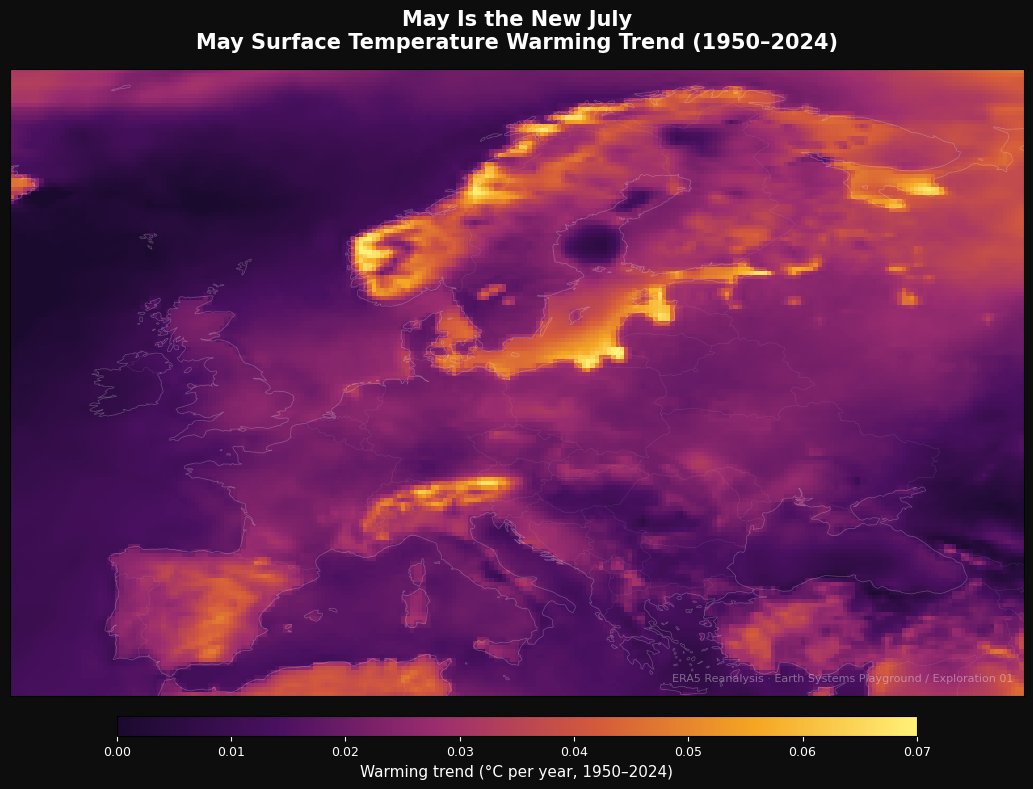

Saved!


In [12]:
fig, ax = plt.subplots(
    figsize=(14, 8),
    subplot_kw={"projection": ccrs.PlateCarree()}
)

fig.patch.set_facecolor("#0d0d0d")
ax.set_facecolor("#0d0d0d")

# Custom colormap: deep purple → burnt orange
from matplotlib.colors import LinearSegmentedColormap
colors = ["#1a0a2e", "#4a1060", "#9b2d6f", "#d45a3c", "#f5a623", "#fff176"]
cmap = LinearSegmentedColormap.from_list("creeping_heat", colors)

# Plot
im = ax.pcolormesh(
    ds.longitude, ds.latitude, trend,
    cmap=cmap, vmin=0, vmax=0.07,
    transform=ccrs.PlateCarree()
)

# Features
ax.add_feature(cfeature.COASTLINE, linewidth=0.5, color="#ffffff40")
ax.add_feature(cfeature.BORDERS, linewidth=0.3, color="#ffffff25")

# Colorbar
cbar = plt.colorbar(im, ax=ax, orientation="horizontal",
                    pad=0.03, fraction=0.03, aspect=40)
cbar.set_label("Warming trend (°C per year, 1950–2024)",
               color="white", fontsize=11)
cbar.ax.xaxis.set_tick_params(color="white")
plt.setp(cbar.ax.xaxis.get_ticklabels(), color="white", fontsize=9)

# Labels
ax.set_title("May Is the New July\nMay Surface Temperature Warming Trend (1950–2024)",
             color="white", fontsize=15, fontweight="bold", pad=15)

ax.text(0.99, 0.02, "ERA5 Reanalysis · Earth Systems Playground / Exploration 01",
        transform=ax.transAxes, color="#ffffff60",
        fontsize=8, ha="right", va="bottom")

plt.tight_layout()
plt.savefig("exploration_01_creeping_heat.png", dpi=150,
            bbox_inches="tight", facecolor="#0d0d0d")
plt.show()
print("Saved!")

/usr/local/lib/python3.12/dist-packages/cartopy/mpl/feature_artist.py:143: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '


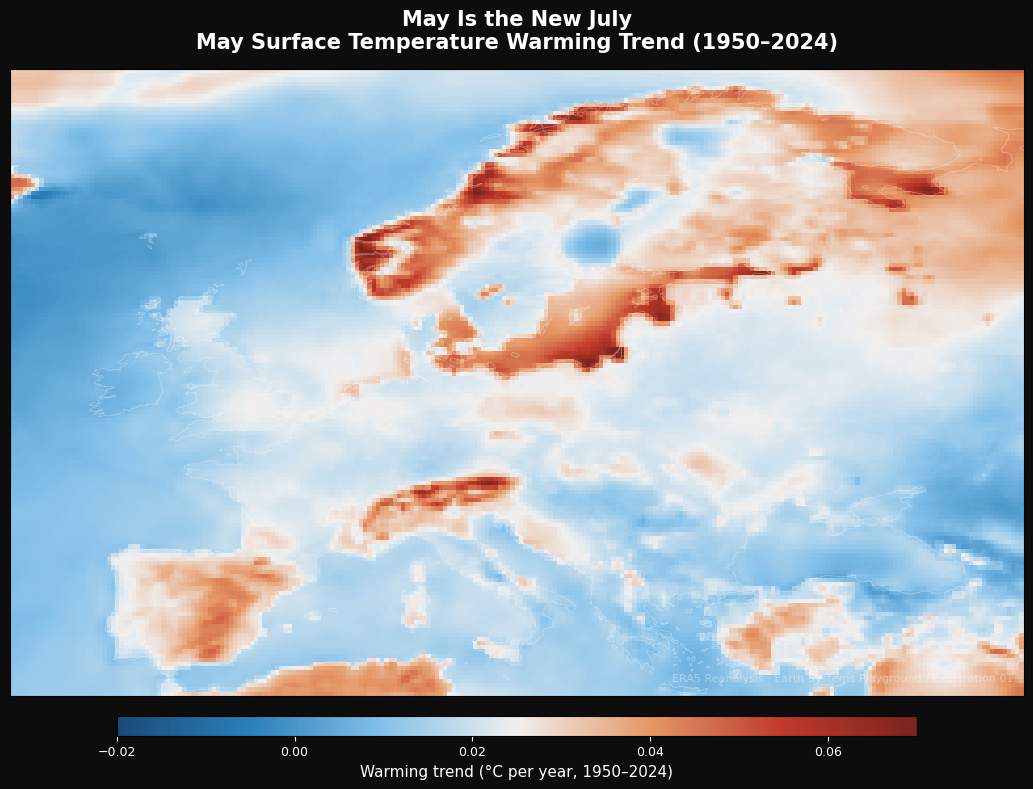

Saved!


In [13]:
fig, ax = plt.subplots(
    figsize=(14, 8),
    subplot_kw={"projection": ccrs.PlateCarree()}
)

fig.patch.set_facecolor("#0d0d0d")
ax.set_facecolor("#0d0d0d")

# Diverging colormap: cooling blue → neutral white → warming orange/red
colors = ["#1a4a7a", "#2980b9", "#85c1e9", "#f0f0f0", "#e59866", "#c0392b", "#7b241c"]
cmap = LinearSegmentedColormap.from_list("diverging_heat", colors)

im = ax.pcolormesh(
    ds.longitude, ds.latitude, trend,
    cmap=cmap, vmin=-0.02, vmax=0.07,
    transform=ccrs.PlateCarree()
)

ax.add_feature(cfeature.COASTLINE, linewidth=0.5, color="#ffffff60")
ax.add_feature(cfeature.BORDERS, linewidth=0.3, color="#ffffff30")

cbar = plt.colorbar(im, ax=ax, orientation="horizontal",
                    pad=0.03, fraction=0.03, aspect=40)
cbar.set_label("Warming trend (°C per year, 1950–2024)",
               color="white", fontsize=11)
cbar.ax.xaxis.set_tick_params(color="white")
plt.setp(cbar.ax.xaxis.get_ticklabels(), color="white", fontsize=9)

ax.set_title("May Is the New July\nMay Surface Temperature Warming Trend (1950–2024)",
             color="white", fontsize=15, fontweight="bold", pad=15)

ax.text(0.99, 0.02, "ERA5 Reanalysis · Earth Systems Playground / Exploration 01",
        transform=ax.transAxes, color="#ffffff60",
        fontsize=8, ha="right", va="bottom")

plt.tight_layout()
plt.savefig("exploration_01_diverging.png", dpi=150,
            bbox_inches="tight", facecolor="#0d0d0d")
plt.show()
print("Saved!")

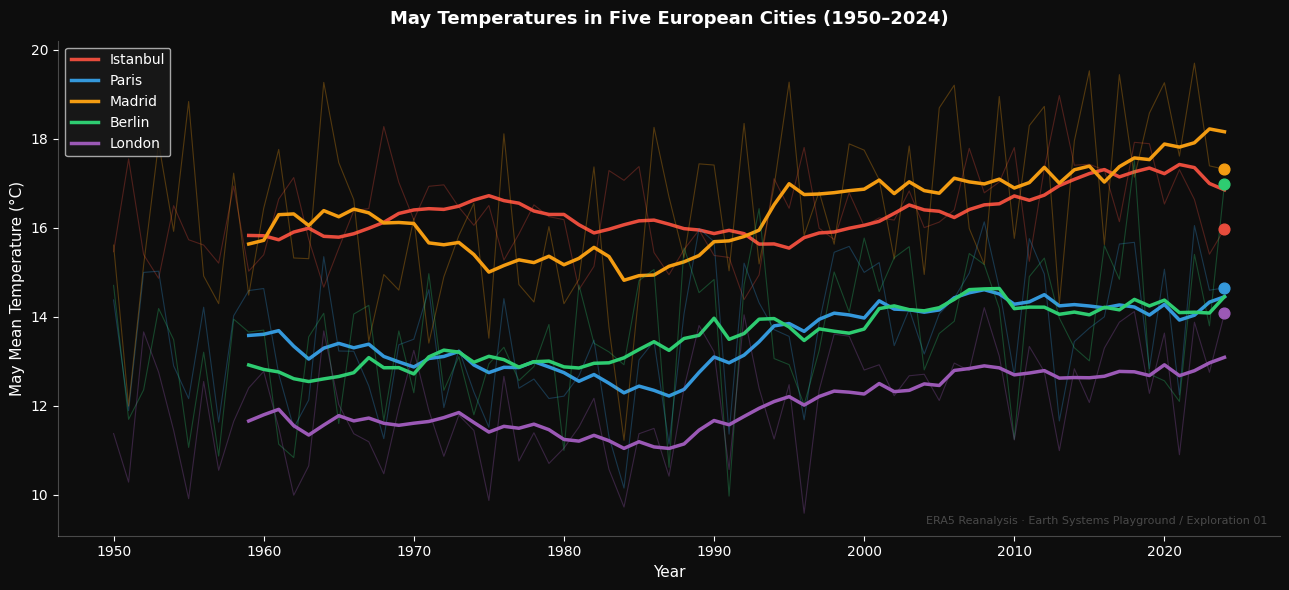

Saved!


In [14]:
# City coordinates
cities = {
    "Istanbul": {"lat": 41.0, "lon": 29.0},
    "Paris":    {"lat": 48.8, "lon": 2.3},
    "Madrid":   {"lat": 40.4, "lon": -3.7},
    "Berlin":   {"lat": 52.5, "lon": 13.4},
    "London":   {"lat": 51.5, "lon": -0.1},
}

years = np.arange(1950, 2025)

fig, ax = plt.subplots(figsize=(13, 6))
fig.patch.set_facecolor("#0d0d0d")
ax.set_facecolor("#0d0d0d")

colors_cities = {
    "Istanbul": "#e74c3c",
    "Paris":    "#3498db",
    "Madrid":   "#f39c12",
    "Berlin":   "#2ecc71",
    "London":   "#9b59b6",
}

for city, coords in cities.items():
    ts = ds["t2m_c"].sel(
        latitude=coords["lat"],
        longitude=coords["lon"],
        method="nearest"
    ).values

    # Thin line for raw data
    ax.plot(years, ts, color=colors_cities[city],
            alpha=0.3, linewidth=0.8)

    # Smoothed trend (10-year rolling)
    smoothed = np.convolve(ts, np.ones(10)/10, mode="valid")
    ax.plot(years[9:], smoothed, color=colors_cities[city],
            linewidth=2.5, label=city)

    # Mark 2024
    ax.scatter(2024, ts[-1], color=colors_cities[city],
               s=60, zorder=5)

# Styling
ax.set_xlabel("Year", color="white", fontsize=11)
ax.set_ylabel("May Mean Temperature (°C)", color="white", fontsize=11)
ax.set_title("May Temperatures in Five European Cities (1950–2024)",
             color="white", fontsize=13, fontweight="bold", pad=12)

ax.tick_params(colors="white")
ax.spines[["top", "right"]].set_visible(False)
ax.spines[["left", "bottom"]].set_color("#ffffff40")

ax.legend(facecolor="#1a1a1a", labelcolor="white",
          framealpha=0.8, fontsize=10)

ax.text(0.99, 0.02, "ERA5 Reanalysis · Earth Systems Playground / Exploration 01",
        transform=ax.transAxes, color="#ffffff40",
        fontsize=8, ha="right", va="bottom")

plt.tight_layout()
plt.savefig("exploration_01_cities.png", dpi=150,
            bbox_inches="tight", facecolor="#0d0d0d")
plt.show()
print("Saved!")

In [ ]:
c.retrieve(
    "reanalysis-era5-single-levels-monthly-means",
    {
        "product_type": "monthly_averaged_reanalysis",
        "variable": "2m_temperature",
        "year": ["2025", "2026"],
        "month": "05",
        "time": "00:00",
        "area": [72, -15, 35, 45],
        "format": "netcdf",
    },
    "era5_may_2025_2026.nc"
)
print("Done.")

In [ ]:
c.retrieve(
    "reanalysis-era5-single-levels-monthly-means",
    {
        "product_type": "monthly_averaged_reanalysis",
        "variable": "2m_temperature",
        "year": "2025",
        "month": "05",
        "time": "00:00",
        "area": [72, -15, 35, 45],
        "format": "netcdf",
    },
    "era5_may_2025.nc"
)
print("Done.")

In [15]:
ds_2025 = xr.open_dataset("/content/era5_may_t2m_2025.nc")
ds_2025["t2m_c"] = ds_2025["t2m"] - 273.15

cities = {
    "Istanbul": {"lat": 41.0, "lon": 29.0},
    "Paris":    {"lat": 48.8, "lon": 2.3},
    "Madrid":   {"lat": 40.4, "lon": -3.7},
    "Berlin":   {"lat": 52.5, "lon": 13.4},
    "London":   {"lat": 51.5, "lon": -0.1},
}

print("2025 loaded!")
for city, coords in cities.items():
    val = ds_2025["t2m_c"].sel(
        latitude=coords["lat"],
        longitude=coords["lon"],
        method="nearest"
    ).values
    print(f"{city}: {float(val):.2f}°C")

2025 loaded!
Istanbul: 16.61°C
Paris: 15.40°C
Madrid: 16.81°C
Berlin: 13.17°C
London: 13.84°C


/tmp/ipykernel_37777/3744426059.py:19: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  print(f"{city}: {float(val):.2f}°C")


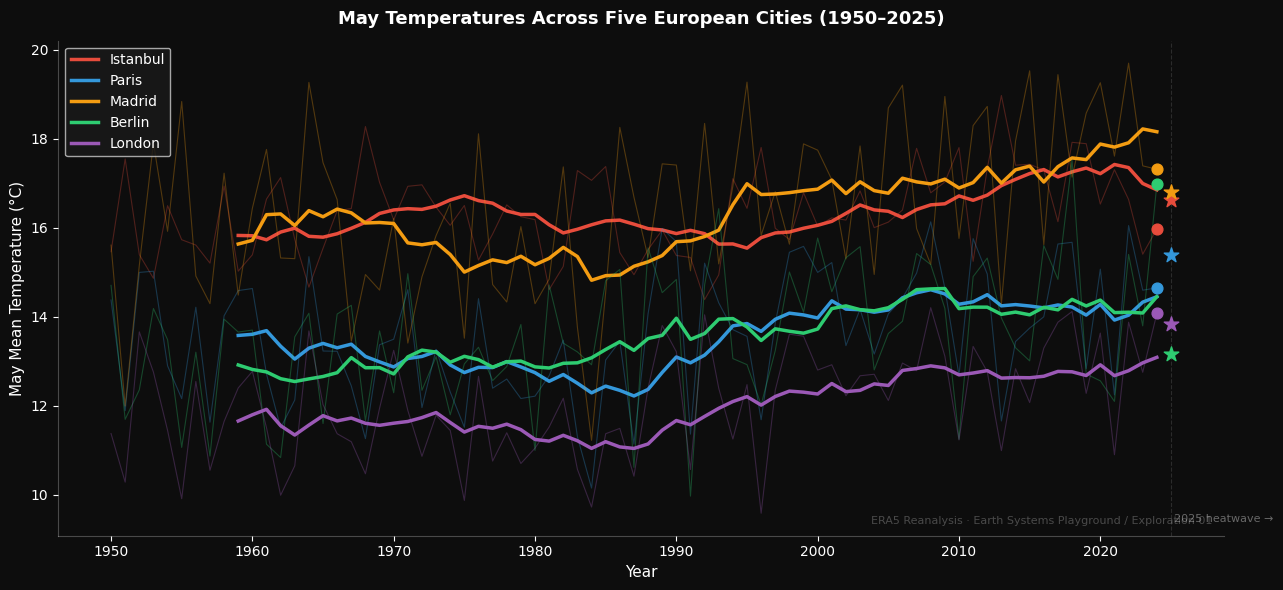

Saved!


In [16]:
fig, ax = plt.subplots(figsize=(13, 6))
fig.patch.set_facecolor("#0d0d0d")
ax.set_facecolor("#0d0d0d")

years = np.arange(1950, 2025)

for city, coords in cities.items():
    ts = ds["t2m_c"].sel(
        latitude=coords["lat"],
        longitude=coords["lon"],
        method="nearest"
    ).values

    # Raw data
    ax.plot(years, ts, color=colors_cities[city], alpha=0.3, linewidth=0.8)

    # Smoothed trend
    smoothed = np.convolve(ts, np.ones(10)/10, mode="valid")
    ax.plot(years[9:], smoothed, color=colors_cities[city],
            linewidth=2.5, label=city)

    # 2024 dot
    ax.scatter(2024, ts[-1], color=colors_cities[city], s=60, zorder=5)

    # 2025 dot — star marker, distinct
    val_2025 = float(ds_2025["t2m_c"].sel(
        latitude=coords["lat"],
        longitude=coords["lon"],
        method="nearest"
    ).values.flat[0])

    ax.scatter(2025, val_2025, color=colors_cities[city],
               s=120, marker="*", zorder=6)

# 2025 annotation
ax.axvline(x=2025, color="#ffffff20", linewidth=0.8, linestyle="--")
ax.text(2025.2, ax.get_ylim()[0] + 0.3, "2025 heatwave →",
        color="#ffffff60", fontsize=8)

# Styling
ax.set_xlabel("Year", color="white", fontsize=11)
ax.set_ylabel("May Mean Temperature (°C)", color="white", fontsize=11)
ax.set_title("May Temperatures Across Five European Cities (1950–2025)",
             color="white", fontsize=13, fontweight="bold", pad=12)

ax.tick_params(colors="white")
ax.spines[["top", "right"]].set_visible(False)
ax.spines[["left", "bottom"]].set_color("#ffffff40")

ax.legend(facecolor="#1a1a1a", labelcolor="white",
          framealpha=0.8, fontsize=10)

ax.text(0.99, 0.02, "ERA5 Reanalysis · Earth Systems Playground / Exploration 01",
        transform=ax.transAxes, color="#ffffff40",
        fontsize=8, ha="right", va="bottom")

plt.tight_layout()
plt.savefig("exploration_01_cities_2025.png", dpi=150,
            bbox_inches="tight", facecolor="#0d0d0d")
plt.show()
print("Saved!")